## Using column transfer

In [221]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, LabelEncoder, StandardScaler, MinMaxScaler, RobustScaler

In [222]:
df = pd.read_csv("/home/tanmoy/Desktop/Phitron/Machine Learning/Module8 - Scaling/Practice/titanic_data_updated.csv")
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
542,543,no,third,"Andersson, Miss. Sigrid Elisabeth",female,11.0,4,2,347082,31.2750,NaN,S
495,496,no,third,"Yousseff, Mr. Gerious",male,NaN,0,0,2627,14.4583,NaN,C
331,332,no,first,"Partner, Mr. Austen",male,45.5,0,0,113043,28.5000,C124,S
477,478,no,third,"Braund, Mr. Lewis Richard",male,29.0,1,0,3460,7.0458,NaN,S
851,852,no,third,"Svensson, Mr. Johan",male,74.0,0,0,347060,7.7750,NaN,S


In [223]:
df.drop(columns=['PassengerId','Name','Ticket'], inplace=True)
df.sample(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
880,yes,second,female,25.0,0,1,26.0000,NaN,S
759,yes,first,female,33.0,0,0,86.5000,B77,S
108,no,third,male,38.0,0,0,7.8958,NaN,S
597,no,third,male,49.0,0,0,0.0000,NaN,S
37,no,third,male,21.0,0,0,8.0500,NaN,S


In [224]:
df['Family_size'] = df['SibSp'] + df['Parch'] + 1

In [225]:
df.sample(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked,Family_size
41,no,second,female,27.0,1,0,21.0000,NaN,S,2
656,no,third,male,NaN,0,0,7.8958,NaN,S,1
31,yes,first,female,NaN,1,0,146.5208,B78,C,2
685,no,second,male,25.0,1,2,41.5792,NaN,C,4
186,yes,third,female,NaN,1,0,15.5000,NaN,Q,2


In [226]:
df.drop(columns=['SibSp','Parch'], inplace= True)
df.sample(5)

,Survived,Pclass,Sex,Age,Fare,Cabin,Embarked,Family_size
611,no,third,male,NaN,7.0500,NaN,S,1
723,no,second,male,50.0,13.0000,NaN,S,1
386,no,third,male,1.0,46.9000,NaN,S,8
122,no,second,male,32.5,30.0708,NaN,C,2
67,no,third,male,19.0,8.1583,NaN,S,1


In [227]:
y = df['Survived']
X = df.drop(columns='Survived')

In [228]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [229]:
impute_transformer = ColumnTransformer(
    transformers=[
        ('age', SimpleImputer(missing_values=np.nan, strategy='mean'), ['Age']),
        ('emabarked', SimpleImputer(missing_values=np.nan, strategy='most_frequent'), ['Embarked']),
        ('cabin', SimpleImputer(missing_values=np.nan, strategy='constant',fill_value="Missing", add_indicator=True), ['Cabin'])
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

impute_transformer.set_output(transform='pandas')

impute_transformer.fit(X_train)
X_train = impute_transformer.transform(X_train)
X_test = impute_transformer.transform(X_test)


In [230]:
X_train.isnull().sum()

Age                       0
Embarked                  0
Cabin                     0
missingindicator_Cabin    0
Pclass                    0
Sex                       0
Fare                      0
Family_size               0
dtype: int64

<Axes: xlabel='Age', ylabel='Density'>

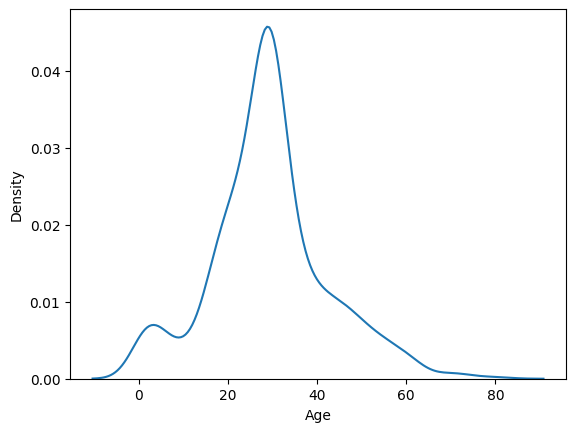

In [231]:
sns.kdeplot(data=X_train, x='Age')

<Axes: xlabel='Fare', ylabel='Density'>

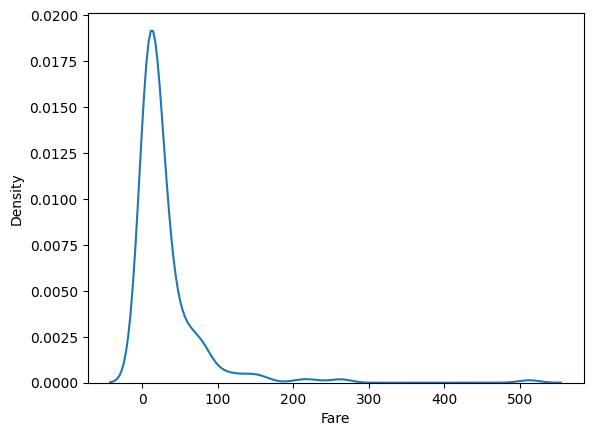

In [232]:
sns.kdeplot(data=X_train, x='Fare')

In [233]:
mn = X_train['Age'].mean()
std = X_train['Age'].std()
z_score = abs(X_train['Age'] - mn) / std

mask = z_score <= 3

X_train = X_train[mask]
y_train = y_train[mask]

In [234]:
q1 = X_train['Fare'].quantile(0.25)
q3 = X_train['Fare'].quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - (iqr * 1.5)
upper_bound = q3 + (iqr * 1.5)
mask = ((X_train['Fare'] < lower_bound) | (X_train['Fare'] > upper_bound))

mask.value_counts()

X_train['Fare'] = X_train['Fare'].clip(lower_bound, upper_bound)

In [235]:
X_train

,Age,Embarked,Cabin,missingindicator_Cabin,Pclass,Sex,Fare,Family_size
445,4.000000,S,A34,False,first,male,65.3000,3
650,29.256353,S,Missing,True,third,male,7.8958,1
172,1.000000,S,Missing,True,third,female,11.1333,3
450,36.000000,S,Missing,True,second,male,27.7500,4
314,43.000000,S,Missing,True,second,male,26.2500,3
...,...,...,...,...,...,...,...,...
106,21.000000,S,Missing,True,third,female,7.6500,1
270,29.256353,S,Missing,True,first,male,31.0000,1
860,41.000000,S,Missing,True,third,male,14.1083,3
435,14.000000,S,B96 B98,False,first,female,65.3000,4


In [236]:
X_train['Cabin_deck'] = X_train['Cabin'].astype(str).str[0]
X_test['Cabin_deck'] = X_test['Cabin'].astype(str).str[0]

In [237]:
encoder_scaler = ColumnTransformer(
    transformers=[
        ('ordinal', OrdinalEncoder(categories=[['third','second', 'first']]), ['Pclass']),
        ('onehot', OneHotEncoder(handle_unknown='ignore',sparse_output=False, drop='first'), ['Cabin_deck', 'Sex', 'Embarked']),
        ('standard', StandardScaler(), ['Age']),
        ('minmax', MinMaxScaler(), ['Fare', 'Family_size'])
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)
encoder_scaler.set_output(transform='pandas')

encoder_scaler.fit(X_train)

X_train = encoder_scaler.transform(X_train)
X_test = encoder_scaler.transform(X_test)

In [238]:
X_train.drop(columns=['Cabin'], inplace=True)
X_test.drop(columns=['Cabin'], inplace=True)

In [239]:
X_test.sample(5)

,Pclass,Cabin_deck_B,Cabin_deck_C,Cabin_deck_D,Cabin_deck_E,Cabin_deck_F,Cabin_deck_G,Cabin_deck_M,Cabin_deck_T,Sex_male,Embarked_Q,Embarked_S,Age,Fare,Family_size,missingindicator_Cabin
398,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,-0.473945,0.160796,0.0,True
653,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.028349,0.119896,0.0,True
462,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.452907,0.589587,0.0,False
541,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,-1.597942,0.478943,0.6,True
338,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.292336,0.123277,0.0,True
